
RQ3 TABLE:

               Accuracy
Raw            0.824000
Imputation     0.820333
Full Pipeline  0.818000


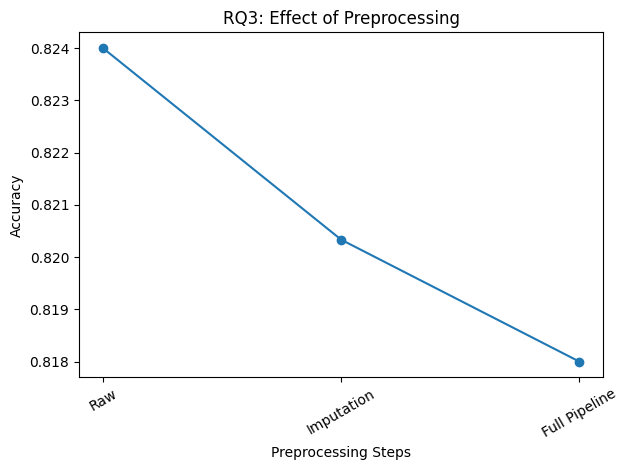


Files saved in: C:\Users\vishwa\kidney disease prediction/outputs/


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# =========================
# 0. CREATE OUTPUT FOLDER
# =========================
os.makedirs("outputs", exist_ok=True)


# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("kidney_disease_balanced.csv")

# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)


# =========================
# 2. SPLIT TARGET
# =========================
y = df["Target"]
X = df.drop("Target", axis=1)


# =========================
# 3. DETECT COLUMNS (FIXED)
# =========================
cat_cols = X.select_dtypes(include=['str']).columns

# fallback if empty
if len(cat_cols) == 0:
    cat_cols = X.select_dtypes(include=['str']).columns

# correct numeric columns
num_cols = X.columns.difference(cat_cols)


# =========================
# 4. ENCODE TARGET
# =========================
y = LabelEncoder().fit_transform(y)


# =========================
# FUNCTION TO EVALUATE MODEL
# =========================
def evaluate(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestClassifier()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    return accuracy_score(y_test, y_pred)


# =========================
# 5. RQ3 SCENARIOS
# =========================
results = {}

# -------- RAW DATA --------
df_raw = df.dropna()

if len(df_raw) > 0:
    y_raw = LabelEncoder().fit_transform(df_raw["Target"])
    X_raw = df_raw.drop("Target", axis=1)

    for col in X_raw.select_dtypes(include=['str']).columns:
        X_raw[col] = LabelEncoder().fit_transform(X_raw[col])

    results["Raw"] = evaluate(X_raw, y_raw)
else:
    results["Raw"] = np.nan


# -------- IMPUTATION --------
X_imp = X.copy()

# Numeric imputation
X_imp[num_cols] = SimpleImputer(strategy='mean').fit_transform(X_imp[num_cols])

# Categorical imputation
X_imp[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X_imp[cat_cols])

# Encoding categorical
for col in cat_cols:
    X_imp[col] = LabelEncoder().fit_transform(X_imp[col])

results["Imputation"] = evaluate(X_imp, y)


# -------- FULL PIPELINE --------
X_full = StandardScaler().fit_transform(X_imp)

results["Full Pipeline"] = evaluate(X_full, y)


# =========================
# 6. CREATE TABLE
# =========================
df_out = pd.DataFrame.from_dict(
    results, orient='index', columns=["Accuracy"]
)

df_out.to_csv("outputs/RQ3_table.csv")

print("\nRQ3 TABLE:\n")
print(df_out)


# =========================
# 7. CREATE FIGURE
# =========================
plt.figure()

plt.plot(df_out.index, df_out["Accuracy"], marker='o')

plt.title("RQ3: Effect of Preprocessing")
plt.xlabel("Preprocessing Steps")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)
plt.tight_layout()

# Save figure
plt.savefig("outputs/RQ3_figure.pdf")

# Display figure
plt.show()


# =========================
# 8. CONFIRM OUTPUT
# =========================
print("\nFiles saved in:", os.getcwd() + "/outputs/")